In [1]:
from sklift.datasets import fetch_hillstrom

bunch = fetch_hillstrom(target_col='visit')
X, y, treat = bunch.data, bunch.target, bunch.treatment

print(X.shape)   # 确认还是 (64000, 8)

(64000, 8)


In [3]:
import numpy as np
import pandas as pd

# .isin([...]) 逐行检查"这个值在不在列表里"，返回一列 True/False
# 结果叫 mask（掩码），True 的行会被保留
mask = treat.isin(['Womens E-Mail', 'No E-Mail'])

# X[mask] 用 True/False 筛行——只留下 mask 为 True 的那些行
# .copy() 复印一份，避免后面改动污染原始的 X
X2 = X[mask].copy()
y2 = y[mask].copy()

# (treat[mask] == 'Womens E-Mail') 逐行比较，得到一列 True/False
# .astype(int) 把 True 变成 1、False 变成 0
# 结果：收到女装邮件的人 = 1，对照组 = 0
t2 = (treat[mask] == 'Womens E-Mail').astype(int)

print(X2.shape)      # 应该是 (约43000, 8)
print(t2.mean())     # 1 的占比，应该约 0.5（两组人数差不多）

(42693, 8)
0.5009486332654065


In [4]:
# .drop(columns=[...]) 删掉指定的列
# history_segment 是 history 的分档，两列信息重复，留信息更细的 history
X2 = X2.drop(columns=['history_segment'])

# pd.get_dummies 叫"独热编码"：把一列文字拆成多列 0/1
#   比如 zip_code 有 Urban/Suburban/Rural 三种值，
#   拆成两列：is_Suburban、is_Urban（Rural 用"两列都是0"表示）
# columns=[...]  指定要拆哪几列
# drop_first=True 每组少留一列，避免冗余（三种值只需两列就能区分）
# dtype=int      输出 0/1 整数，而不是 True/False
X2 = pd.get_dummies(X2, columns=['zip_code', 'channel'],
                    drop_first=True, dtype=int)

# .dtypes 列出每一列的数据类型
# 检查点：不应该再出现 object（object 就是"文字"）
print(X2.dtypes)

recency                 int64
history               float64
mens                    int64
womens                  int64
newbie                  int64
zip_code_Surburban      int32
zip_code_Urban          int32
channel_Phone           int32
channel_Web             int32
dtype: object


In [5]:
from sklearn.model_selection import train_test_split

# 把 treatment 和 y 两个信息拼成一个标签，比如 "1_0"、"0_1"
# 目的：让切分时同时照顾这两个维度的比例
strat = t2.astype(str) + '_' + y2.astype(str)

# train_test_split 把数据随机切成训练集和测试集
#   前面三个参数 X2, y2, t2：三份数据一起切，保证行号对得上
#   test_size=0.3    测试集占 30%
#   random_state=42  固定随机种子，保证每次跑结果一样（可复现）
#   stratify=strat   按 strat 分层——训练集和测试集里各类比例保持一致
# 返回 6 个结果，顺序是：X训练, X测试, y训练, y测试, t训练, t测试
X_tr, X_te, y_tr, y_te, t_tr, t_te = train_test_split(
    X2, y2, t2, test_size=0.3, random_state=42, stratify=strat
)

print(X_tr.shape, X_te.shape)   # 约 30000 和 13000

(29885, 9) (12808, 9)


D:\Program files\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Program files\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "D:\Program files\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Program files\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "D:\Program files\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, arg

平均增益预测: 0.04616285476068236
Qini AUC: 0.010169850062035196


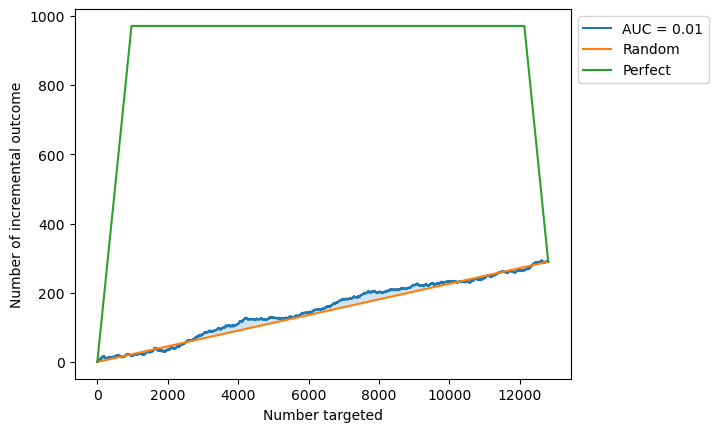

In [7]:
# ---- 版本兼容补丁：sklift 0.5.1 + 新版 sklearn ----
import sklearn.utils
from sklearn.utils._optional_dependencies import check_matplotlib_support
sklearn.utils.check_matplotlib_support = check_matplotlib_support
# ------------------------------------------------

from lightgbm import LGBMClassifier
from sklift.models import TwoModels
from sklift.metrics import qini_auc_score
from sklift.viz import plot_qini_curve
import matplotlib.pyplot as plt

tm = TwoModels(
    estimator_trmnt=LGBMClassifier(random_state=42, verbose=-1),
    estimator_ctrl=LGBMClassifier(random_state=42, verbose=-1),
    method='vanilla'
)

tm.fit(X_tr, y_tr, t_tr)
uplift = tm.predict(X_te)

print('平均增益预测:', uplift.mean())
print('Qini AUC:', qini_auc_score(y_te, uplift, t_te))

plot_qini_curve(y_te, uplift, t_te)
plt.savefig('../figures/qini_curve.png', dpi=150, bbox_inches='tight')
plt.show()